# 02 — Anomaly Detection: Bank Transactions

We flag potentially fraudulent transactions three independent ways and check whether they agree:

1. A simple **rule-based** score
2. **K-Means** clustering (distance-to-centroid)
3. **DBSCAN** (density-based outlier labeling)

Agreement across independent methods is a basic form of validation: if three different approaches point at the same transactions, that's a much stronger signal than any single method alone.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

df = pd.read_csv('../data/raw/bank_transactions_data_2.csv')
df.shape

(2512, 16)

## 1. Rule-based suspicion score

Based on the EDA in notebook 01, we use two independent signals:

- **Amount outlier**: transaction amount above the IQR upper fence (`Q3 + 1.5*IQR`)
- **Login outlier**: 2 or more login attempts

Each transaction gets a score from 0–2 depending on how many rules it trips.


In [2]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
upper_limit = Q3 + 1.5*(Q3-Q1)

df['AmountFlag'] = (df['TransactionAmount'] > upper_limit).astype(int)
df['LoginFlag'] = (df['LoginAttempts'] >= 2).astype(int)
df['SuspicionScore'] = df['AmountFlag'] + df['LoginFlag']

df['SuspicionScore'].value_counts().sort_index()

SuspicionScore
0    2282
1     225
2       5
Name: count, dtype: int64

In [3]:
df[df['SuspicionScore']==2][['TransactionID','TransactionAmount','LoginAttempts','TransactionType','CustomerAge']]

,TransactionID,TransactionAmount,LoginAttempts,TransactionType,CustomerAge
274,TX000275,1176.28,5,Credit,54
898,TX000899,1531.31,4,Debit,18
1156,TX001157,917.81,2,Debit,64
1213,TX001214,1192.20,5,Credit,60
2149,TX002150,1250.94,2,Debit,36


**Note on independence:** the correlation between `TransactionAmount` and `LoginAttempts` is essentially zero (checked separately), confirming these are two distinct signals rather than one signal counted twice.


## 2. K-Means clustering

We standardize `TransactionAmount` and `LoginAttempts` (required since they're on very different scales), then use the elbow method to choose the number of clusters.


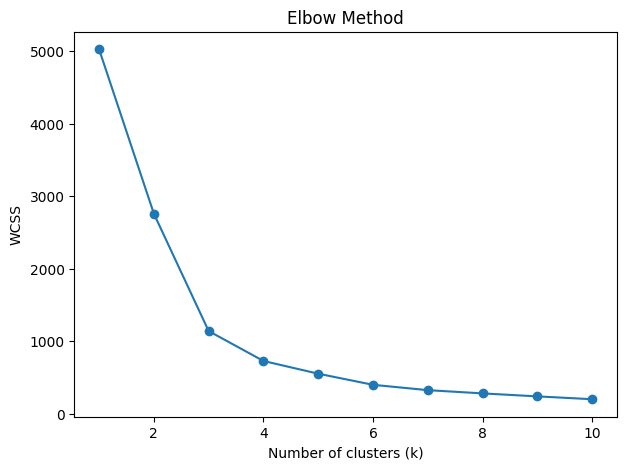

In [4]:
X = df[['TransactionAmount','LoginAttempts']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [5]:
pct_drop = [ (wcss[i-1]-wcss[i])/wcss[i-1]*100 for i in range(1,len(wcss)) ]
for k, pd_ in zip(range(2,11), pct_drop):
    print(f"k={k}: {pd_:.1f}% drop from previous")

k=2: 45.1% drop from previous
k=3: 58.7% drop from previous
k=4: 36.1% drop from previous
k=5: 24.1% drop from previous
k=6: 27.7% drop from previous
k=7: 18.4% drop from previous
k=8: 13.7% drop from previous
k=9: 14.6% drop from previous
k=10: 16.2% drop from previous


The percentage drop in WCSS stabilizes into a fairly flat, low range (~13–18%) from **k=6** onward, compared to larger and more erratic drops before it (24–59%). We select **k=6**.

(This is a judgment call — the elbow method doesn't have a single universally "correct" answer. A case could also be made for k=3, where the single largest drop occurs. We document the reasoning behind our choice rather than picking a number arbitrarily.)


In [6]:
km = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_scaled)

centers = km.cluster_centers_
df['DistanceToCentroid'] = np.linalg.norm(X_scaled - centers[df['Cluster']], axis=1)

df.sort_values('DistanceToCentroid', ascending=False).head(10)[
    ['TransactionID','TransactionAmount','LoginAttempts','Cluster','DistanceToCentroid','SuspicionScore']
]

,TransactionID,TransactionAmount,LoginAttempts,Cluster,DistanceToCentroid,SuspicionScore
898,TX000899,1531.31,4,2,4.361944,2
1213,TX001214,1192.20,5,2,3.228953,2
274,TX000275,1176.28,5,2,3.176275,2
653,TX000654,1919.11,1,3,2.367892,1
1438,TX001439,1831.02,1,3,2.066108,1
340,TX000341,1830.00,1,3,2.062613,1
772,TX000773,827.14,4,2,2.045683,1
1634,TX001635,1762.28,1,3,1.830616,1
1156,TX001157,917.81,2,5,1.799024,2
2124,TX002125,737.46,4,2,1.769250,1


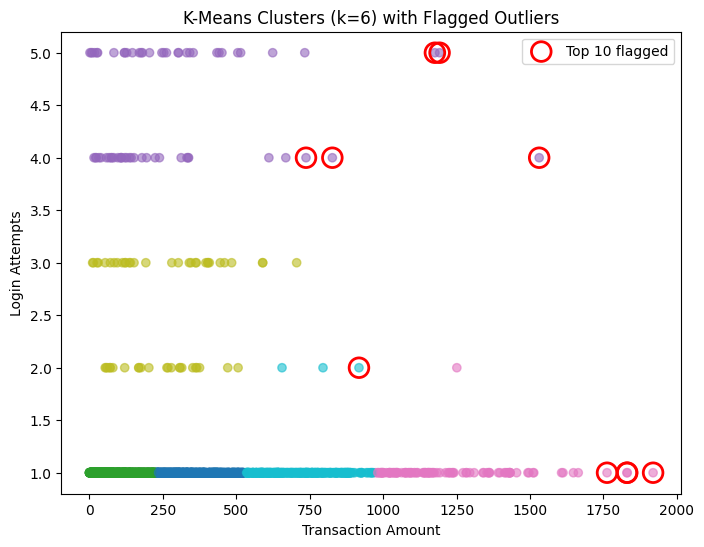

In [7]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['TransactionAmount'], df['LoginAttempts'], c=df['Cluster'], cmap='tab10', alpha=0.6)
flagged = df.sort_values('DistanceToCentroid', ascending=False).head(10)
plt.scatter(flagged['TransactionAmount'], flagged['LoginAttempts'], facecolors='none', edgecolors='red', s=200, linewidths=2, label='Top 10 flagged')
plt.xlabel('Transaction Amount')
plt.ylabel('Login Attempts')
plt.title('K-Means Clusters (k=6) with Flagged Outliers')
plt.legend()
plt.show()

## 3. DBSCAN

Unlike K-Means, DBSCAN doesn't require specifying the number of clusters upfront — it identifies dense regions automatically and labels points that don't belong to any dense region as outliers (`label = -1`). We add `TransactionDuration` as a third feature.


In [8]:
X3 = df[['TransactionAmount','LoginAttempts','TransactionDuration']]
X3_scaled = StandardScaler().fit_transform(X3)

dbscan = DBSCAN(eps=1.0, min_samples=5)
df['DBSCAN_Label'] = dbscan.fit_predict(X3_scaled)

df['DBSCAN_Label'].value_counts().sort_index()

DBSCAN_Label
-1      16
 0    2389
 1      29
 2      28
 3      23
 4      27
Name: count, dtype: int64

In [9]:
dbscan_outliers = df[df['DBSCAN_Label']==-1]
overlap = dbscan_outliers[dbscan_outliers['SuspicionScore']>=1]
print(f"DBSCAN outliers: {len(dbscan_outliers)}")
print(f"Of those, also flagged by the rule-based score: {len(overlap)} ({len(overlap)/len(dbscan_outliers)*100:.0f}%)")

DBSCAN outliers: 16
Of those, also flagged by the rule-based score: 16 (100%)


## Summary

All 16 DBSCAN-identified outliers were also flagged by the independent rule-based score — full agreement between two unrelated methods (plus K-Means pointing at largely the same transactions). This convergence across three different techniques gives reasonable confidence that these transactions represent a genuine behavioral pattern, not an artifact of any single method's assumptions.

**Limitation:** none of this is validated against ground-truth fraud labels, since this dataset doesn't have any. It identifies *statistical outliers*, which is a reasonable but distinct concept from *confirmed fraud* — outliers merit investigation, not automatic action.

Next: `03_supervised_fraud_model.ipynb`, using a labeled dataset to build and evaluate an actual fraud classifier.
